In [1]:
from pathlib import Path
import random
import json

import numpy as np
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm

from IPPy.utilities.metrics import PSNR, SSIM

from utils.data_utils import load_normalized_image

# ============================================================
# CONFIGURAZIONE -- percorsi locali
# ============================================================

TEST_DIR = Path("../dataset_resized/test_resized")          # ground truth: root/paziente/slice.png
GANDPS_DIR = Path("../gan_dps_reconstructions/test")          # ricostruzioni GAN+DPS: root/n_angoli/paziente/slice.npy

RESULTS_DIR = Path("../results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

JSON_DIR = RESULTS_DIR / "json"
JSON_DIR.mkdir(parents=True, exist_ok=True)

EXAMPLES_DIR = RESULTS_DIR / "example_comparison"
EXAMPLES_DIR.mkdir(parents=True, exist_ok=True)

N_ANGLES_CONFIGS = [90, 45, 30, 15]

ANGLE_INTERVALS = {
    90: "[-45°, 45°]",
    45: "[-45°, 45°]",
    30: "(-30°, 30°)",
    15: "(-30°, 30°)",
}

In [2]:
# ============================================================
# Controllo corrispondenza e range/dtype delle ricostruzioni GAN+DPS
# (il generatore ha un sigmoid finale, quindi l'output e' gia'
# matematicamente vincolato in (0,1) -- il clip qui e' solo una rete
# di sicurezza, coerente con gli altri metodi)
# ============================================================

def load_gandps_reconstruction(path: Path) -> np.ndarray:
    image = np.load(path).astype(np.float32)
    return np.clip(image, 0.0, 1.0)


for n_angles in N_ANGLES_CONFIGS:
    gandps_paths = sorted((GANDPS_DIR / str(n_angles)).rglob("*.npy"))

    global_min, global_max = np.inf, -np.inf
    pixels_below_0 = pixels_above_1 = total_pixels = 0
    missing_gt = 0

    for gandps_path in gandps_paths:
        rel = gandps_path.relative_to(GANDPS_DIR / str(n_angles))
        gt_path = (TEST_DIR / rel).with_suffix(".png")
        if not gt_path.exists():
            missing_gt += 1

        image = np.load(gandps_path)
        global_min = min(global_min, image.min())
        global_max = max(global_max, image.max())
        pixels_below_0 += np.sum(image < 0)
        pixels_above_1 += np.sum(image > 1)
        total_pixels += image.size

    print(f"\n{n_angles} angoli {ANGLE_INTERVALS[n_angles]}")
    print(f"Ricostruzioni GAN+DPS: {len(gandps_paths)}")
    print(f"Ground truth mancanti: {missing_gt}")
    print(f"Range: [{global_min:.4f}, {global_max:.4f}]")
    print(f"Pixel sotto 0: {100 * pixels_below_0 / total_pixels:.6f}%")
    print(f"Pixel sopra 1: {100 * pixels_above_1 / total_pixels:.6f}%")


90 angoli [-45°, 45°]
Ricostruzioni GAN+DPS: 327
Ground truth mancanti: 0
Range: [0.0000, 0.9993]
Pixel sotto 0: 0.000000%
Pixel sopra 1: 0.000000%

45 angoli [-45°, 45°]
Ricostruzioni GAN+DPS: 327
Ground truth mancanti: 0
Range: [0.0000, 0.9991]
Pixel sotto 0: 0.000000%
Pixel sopra 1: 0.000000%

30 angoli (-30°, 30°)
Ricostruzioni GAN+DPS: 327
Ground truth mancanti: 0
Range: [0.0000, 0.9553]
Pixel sotto 0: 0.000000%
Pixel sopra 1: 0.000000%

15 angoli (-30°, 30°)
Ricostruzioni GAN+DPS: 327
Ground truth mancanti: 0
Range: [0.0000, 0.9547]
Pixel sotto 0: 0.000000%
Pixel sopra 1: 0.000000%


In [3]:
# ============================================================
# Calcolo PSNR e SSIM tra ricostruzioni GAN+DPS e ground truth,
# confronto predizione-per-predizione su tutto il test set
# ============================================================

results_gandps_vs_gt = {}

for n_angles in N_ANGLES_CONFIGS:

    gandps_paths = sorted((GANDPS_DIR / str(n_angles)).rglob("*.npy"))

    psnr_values = []
    ssim_values = []
    slice_names = []

    for gandps_path in tqdm(gandps_paths, desc=f"Metriche GAN+DPS [{n_angles} angoli]"):

        rel = gandps_path.relative_to(GANDPS_DIR / str(n_angles))
        gt_path = (TEST_DIR / rel).with_suffix(".png")

        if not gt_path.exists():
            print(f"Ground truth non trovata per {gandps_path}")
            continue

        gt = load_normalized_image(gt_path)
        gandps = load_gandps_reconstruction(gandps_path)

        if gt.shape != gandps.shape:
            print(f"Shape diverse per {gandps_path}: GT={gt.shape}, GAN+DPS={gandps.shape}")
            continue

        x_true = torch.from_numpy(gt).float().unsqueeze(0).unsqueeze(0)
        x_gandps = torch.from_numpy(gandps).float().unsqueeze(0).unsqueeze(0)

        psnr_values.append(float(PSNR(x_gandps, x_true)))
        ssim_values.append(float(SSIM(x_gandps, x_true)))
        slice_names.append(str(rel))

    results_gandps_vs_gt[n_angles] = {
        "slice": slice_names,
        "PSNR": psnr_values,
        "SSIM": ssim_values,
    }

Metriche GAN+DPS [15 angoli]: 100%|██████████| 327/327 [00:04<00:00, 74.23it/s]


In [4]:
# ============================================================
# Risultati medi di PSNR e SSIM per ciascuna configurazione angolare
# -- questa e' la metrica finale da riportare nella relazione
# ============================================================

print("RISULTATI GAN+DPS SUL TEST SET")

for n_angles in N_ANGLES_CONFIGS:

    psnr_values = np.array(results_gandps_vs_gt[n_angles]["PSNR"])
    ssim_values = np.array(results_gandps_vs_gt[n_angles]["SSIM"])

    print(f"\n{n_angles} angoli {ANGLE_INTERVALS[n_angles]}")
    print(f"Numero slice: {len(psnr_values)}")
    print(f"PSNR medio: {psnr_values.mean():.2f} ± {psnr_values.std():.2f} dB")
    print(f"SSIM medio: {ssim_values.mean():.4f} ± {ssim_values.std():.4f}")

RISULTATI GAN+DPS SUL TEST SET

90 angoli [-45°, 45°]
Numero slice: 327
PSNR medio: 16.05 ± 1.43 dB
SSIM medio: 0.2914 ± 0.0427

45 angoli [-45°, 45°]
Numero slice: 327
PSNR medio: 15.97 ± 1.40 dB
SSIM medio: 0.2893 ± 0.0425

30 angoli (-30°, 30°)
Numero slice: 327
PSNR medio: 15.48 ± 1.29 dB
SSIM medio: 0.2845 ± 0.0363

15 angoli (-30°, 30°)
Numero slice: 327
PSNR medio: 15.30 ± 1.35 dB
SSIM medio: 0.2799 ± 0.0393


In [5]:
# ============================================================
# Salvataggio riepilogo in JSON
# ============================================================

summary_out = {
    str(n_angles): {
        "psnr_mean": float(np.mean(results_gandps_vs_gt[n_angles]["PSNR"])),
        "psnr_std": float(np.std(results_gandps_vs_gt[n_angles]["PSNR"])),
        "ssim_mean": float(np.mean(results_gandps_vs_gt[n_angles]["SSIM"])),
        "ssim_std": float(np.std(results_gandps_vs_gt[n_angles]["SSIM"])),
        "n_slices": len(results_gandps_vs_gt[n_angles]["PSNR"]),
        "psnr_values": [float(v) for v in results_gandps_vs_gt[n_angles]["PSNR"]],
        "ssim_values": [float(v) for v in results_gandps_vs_gt[n_angles]["SSIM"]],
    }
    for n_angles in N_ANGLES_CONFIGS
}

out_path = JSON_DIR / "gandps_test_metrics.json"
with open(out_path, "w") as f:
    json.dump(summary_out, f, indent=2)

print(f"Riepilogo salvato in: {out_path}")


Riepilogo salvato in: ..\results\json\gandps_test_metrics.json


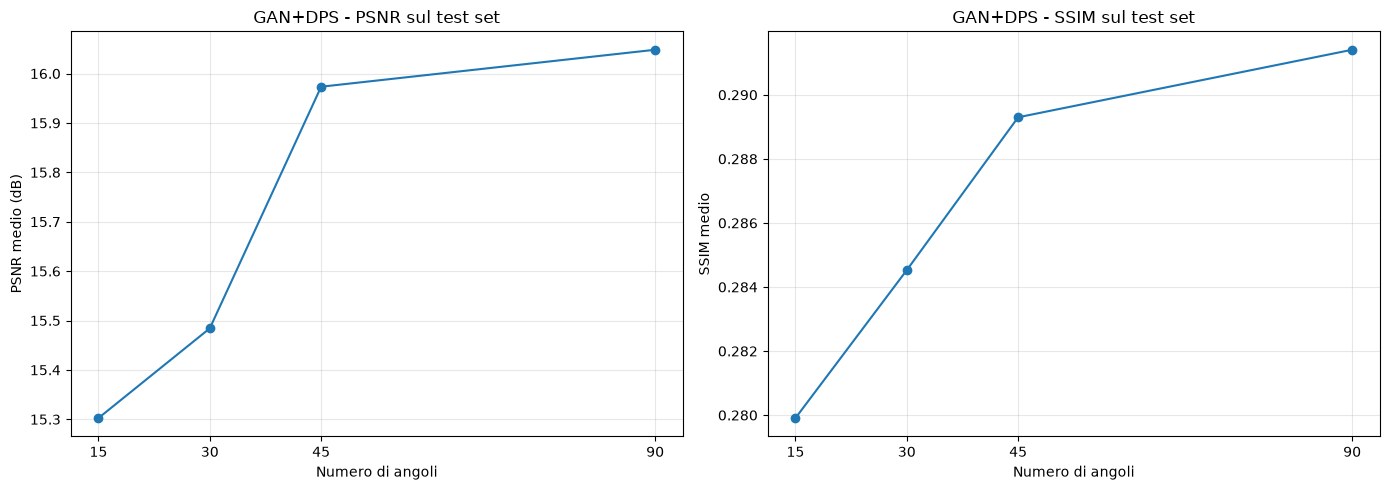

In [6]:
# ============================================================
# Grafico PSNR e SSIM medi per configurazione angolare
# ============================================================

psnr_means = [
    np.mean(results_gandps_vs_gt[n_angles]["PSNR"])
    for n_angles in N_ANGLES_CONFIGS
]

ssim_means = [
    np.mean(results_gandps_vs_gt[n_angles]["SSIM"])
    for n_angles in N_ANGLES_CONFIGS
]

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].plot(N_ANGLES_CONFIGS, psnr_means, marker="o")
axs[0].set_xlabel("Numero di angoli")
axs[0].set_ylabel("PSNR medio (dB)")
axs[0].set_title("GAN+DPS - PSNR sul test set")
axs[0].set_xticks(N_ANGLES_CONFIGS)
axs[0].grid(alpha=0.3)

axs[1].plot(N_ANGLES_CONFIGS, ssim_means, marker="o")
axs[1].set_xlabel("Numero di angoli")
axs[1].set_ylabel("SSIM medio")
axs[1].set_title("GAN+DPS - SSIM sul test set")
axs[1].set_xticks(N_ANGLES_CONFIGS)
axs[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


Slice scelta a caso: C081\77.npy


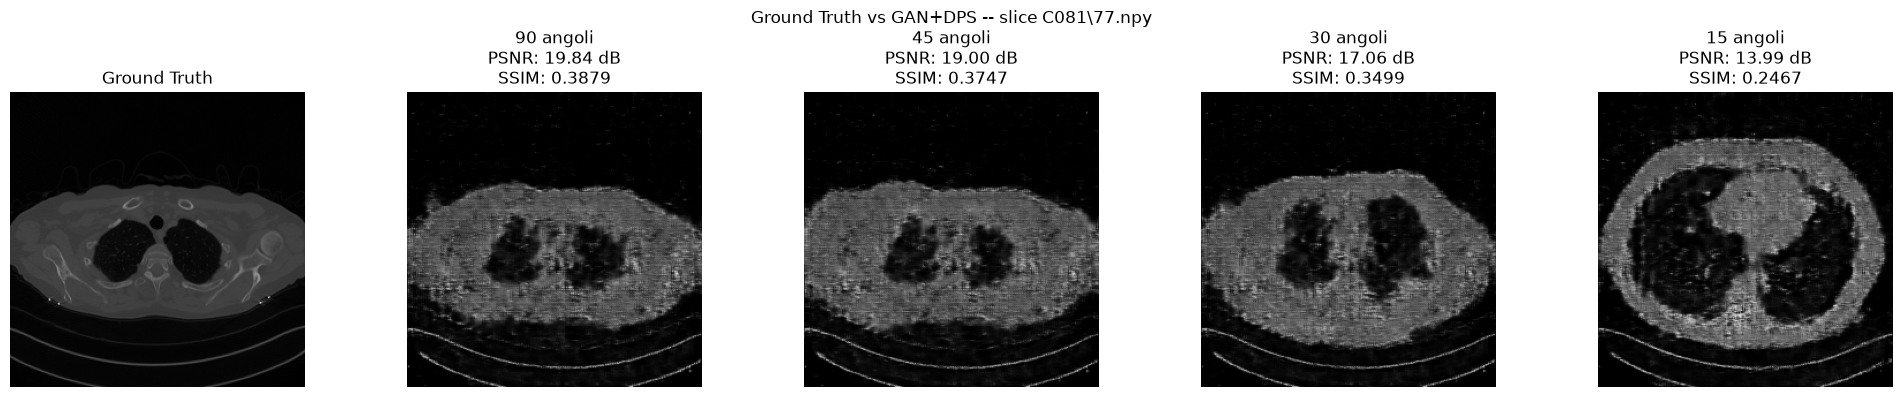

In [7]:
# ============================================================
# Confronto visivo: la STESSA slice mostrata su tutti e 4 gli angoli,
# Ground Truth vs GAN+DPS (layout orizzontale)
# ============================================================

random.seed(105)  # stesso seed usato in tutti gli altri notebook di valutazione

reference_paths = sorted((GANDPS_DIR / "90").rglob("*.npy"))
demo_rel_path = random.choice(reference_paths).relative_to(GANDPS_DIR / "90")
print(f"Slice scelta a caso: {demo_rel_path}")

gt_path = (TEST_DIR / demo_rel_path).with_suffix(".png")
gt = load_normalized_image(gt_path)
gt_t = torch.from_numpy(gt).float().unsqueeze(0).unsqueeze(0)

fig, axs = plt.subplots(1, len(N_ANGLES_CONFIGS) + 1, figsize=(4 * (len(N_ANGLES_CONFIGS) + 1), 4))

axs[0].imshow(gt, cmap="gray", vmin=0, vmax=1)
axs[0].set_title("Ground Truth")
axs[0].axis("off")

for ax, n_angles in zip(axs[1:], N_ANGLES_CONFIGS):
    gandps = load_gandps_reconstruction(GANDPS_DIR / str(n_angles) / demo_rel_path)
    gandps_t = torch.from_numpy(gandps).float().unsqueeze(0).unsqueeze(0)
    psnr_val = float(PSNR(gandps_t, gt_t))
    ssim_val = float(SSIM(gandps_t, gt_t))

    ax.imshow(gandps, cmap="gray", vmin=0, vmax=1)
    ax.set_title(
        f"{n_angles} angoli\n"
        f"PSNR: {psnr_val:.2f} dB\n"
        f"SSIM: {ssim_val:.4f}"
    )
    ax.axis("off")

plt.suptitle(f"Ground Truth vs GAN+DPS -- slice {demo_rel_path}")
plt.tight_layout()
plt.savefig(EXAMPLES_DIR / "demo_gandps_vs_gt.png", dpi=150)
plt.show()
